# Business Load Prediction - Exploratory Data Analysis

This notebook is the main EDA artifact after raw understanding and staging validation.

The goal is to decide whether the cleaned analytical data is ready for feature engineering and modeling.

EDA focuses on traffic, driver pressure, time patterns, area quality, technical pressure, and leakage-safe feature relevance.

In [1]:
# pathlib gives clean file path handling.
from pathlib import Path

# numpy is used for safe numeric calculations.
import numpy as np

# pandas is used for tables, grouping, and correlation analysis.
import pandas as pd

# matplotlib is used for simple plots.
import matplotlib.pyplot as plt

# Show more columns and rows so EDA tables are readable.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 160)

# Detect the project root whether the notebook runs from the project root or notebooks/.
current_working_directory_path = Path.cwd()

if (current_working_directory_path / "data").exists():
    project_root_path = current_working_directory_path
else:
    project_root_path = current_working_directory_path.parent

# Analytical datasets are the primary input for EDA.
business_load_hourly_file_path = project_root_path / "data/analytical/business_load_hourly.parquet"
technical_pressure_hourly_file_path = project_root_path / "data/analytical/technical_pressure_hourly.parquet"

# Staging datasets are used only for light quality checks that are not available in analytical tables.
orders_staging_folder_path = project_root_path / "data/staging/orders_clean"
delivery_requests_staging_folder_path = project_root_path / "data/staging/delivery_requests_clean"
performance_logs_staging_folder_path = project_root_path / "data/staging/performance_logs_clean"

# Save only important plots. Notebook outputs remain the main EDA artifact.
eda_plot_output_folder_path = project_root_path / "reports/EDA/plots"
eda_plot_output_folder_path.mkdir(parents=True, exist_ok=True)

## 2. Load Analytical Data

We load hourly datasets because EDA decisions for modeling should be made at the same grain as the future model: `area + hour`.

In [2]:
# Load business hourly data.
business_hourly = pd.read_parquet(business_load_hourly_file_path)

# Load technical hourly data.
technical_hourly = pd.read_parquet(technical_pressure_hourly_file_path)

# Sort business rows by area and time so lag/lead logic is correct later.
business_hourly = business_hourly.sort_values(["area", "window_start"]).reset_index(drop=True)

# Sort technical rows by endpoint/method/time for readable inspection.
technical_hourly = technical_hourly.sort_values(["endpoint", "method", "window_start"]).reset_index(drop=True)

# Show basic dataset shapes.
pd.DataFrame([
    {
        "dataset_name": "business_hourly",
        "rows": len(business_hourly),
        "columns": len(business_hourly.columns),
        "min_time": business_hourly["window_start"].min(),
        "max_time": business_hourly["window_start"].max(),
    },
    {
        "dataset_name": "technical_hourly",
        "rows": len(technical_hourly),
        "columns": len(technical_hourly.columns),
        "min_time": technical_hourly["window_start"].min(),
        "max_time": technical_hourly["window_start"].max(),
    },
])

,dataset_name,rows,columns,min_time,max_time
0,business_hourly,1887726,36,2022-01-01 00:00:00+00:00,2026-05-19 12:00:00+00:00
1,technical_hourly,102211,8,2025-07-17 15:00:00+00:00,2026-05-19 14:00:00+00:00


## 3. Analytical Schema Check

This confirms the EDA notebook matches the current lean schema.

In [3]:
# Display business hourly columns.
pd.DataFrame({"business_hourly_column": business_hourly.columns})

,business_hourly_column
0,window_start
1,area
2,orders_count
3,completed_orders
4,canceled_orders
5,failed_orders
6,unique_merchants_count
7,unique_branches_count
8,country
9,driver_requests_count


In [4]:
# Confirm removed v1-excluded columns are not in the business analytical dataset.
removed_column_names = [
    "avg_amount",
    "total_amount",
    "avg_delivery_fee",
    "p95_delivery_fee",
    "avg_driver_search_trials",
]

pd.DataFrame([
    {
        "column_name": column_name,
        "exists_in_business_hourly": column_name in business_hourly.columns,
    }
    for column_name in removed_column_names
])

,column_name,exists_in_business_hourly
0,avg_amount,False
1,total_amount,False
2,avg_delivery_fee,False
3,p95_delivery_fee,False
4,avg_driver_search_trials,False


## 4. Data Quality At Hourly Grain

This section checks whether the analytical tables are structurally safe for EDA and modeling.

In [5]:
# Check duplicate area-hour records.
business_duplicate_area_hour_count = business_hourly.duplicated(["area", "window_start"]).sum()

# Check missing area and timestamp values.
business_missing_area_count = business_hourly["area"].isna().sum()
business_missing_window_start_count = business_hourly["window_start"].isna().sum()

# Check negative count values because counts should never be negative.
business_count_column_names = [
    "orders_count",
    "completed_orders",
    "canceled_orders",
    "failed_orders",
    "other_orders",
    "driver_requests_count",
    "accepted_requests",
    "rejected_requests",
    "ignored_requests",
    "pending_requests",
]

business_negative_count_rows = business_hourly[business_count_column_names].lt(0).any(axis=1).sum()

# Check accounting consistency for order statuses.
order_status_total_mismatch_count = (
    business_hourly["completed_orders"]
    + business_hourly["canceled_orders"]
    + business_hourly["failed_orders"]
    + business_hourly["other_orders"]
    != business_hourly["orders_count"]
).sum()

# Check accounting consistency for request statuses.
request_status_total_mismatch_count = (
    business_hourly["accepted_requests"]
    + business_hourly["rejected_requests"]
    + business_hourly["ignored_requests"]
    + business_hourly["pending_requests"]
    > business_hourly["driver_requests_count"]
).sum()

pd.DataFrame([{
    "duplicate_area_hour_count": business_duplicate_area_hour_count,
    "missing_area_count": business_missing_area_count,
    "missing_window_start_count": business_missing_window_start_count,
    "negative_count_rows": business_negative_count_rows,
    "order_status_total_mismatch_count": order_status_total_mismatch_count,
    "request_status_total_mismatch_count": request_status_total_mismatch_count,
}])

,duplicate_area_hour_count,missing_area_count,missing_window_start_count,negative_count_rows,order_status_total_mismatch_count,request_status_total_mismatch_count
0,0,0,0,0,0,0


## 5. Area Quality And Modeling Eligibility

The model predicts by `area + hour`, so area quality and volume distribution are critical.

Sparse areas should not be modeled with the same strategy as high-volume areas.

In [6]:
# Read only the columns needed to summarize area normalization quality.
orders_area_quality = pd.read_parquet(
    orders_staging_folder_path,
    columns=["order_id", "area", "city", "area_raw", "area_quality_flag", "createdAt"],
)

# Summarize how the area was created during cleaning.
area_quality_summary = (
    orders_area_quality["area_quality_flag"]
    .value_counts(dropna=False)
    .rename_axis("area_quality_flag")
    .reset_index(name="orders_count")
)

area_quality_summary["orders_share"] = area_quality_summary["orders_count"] / area_quality_summary["orders_count"].sum()

area_quality_summary

,area_quality_flag,orders_count,orders_share
0,city_as_area,4251573,0.897427
1,city_as_area_with_sub_area,411547,0.086870
2,area_raw_as_area,44256,0.009342
3,invalid_area,30140,0.006362


In [7]:
# Build an area-level business summary from hourly data.
area_volume_summary = (
    business_hourly
    .groupby("area", as_index=False)
    .agg(
        total_orders=("orders_count", "sum"),
        total_driver_requests=("driver_requests_count", "sum"),
        observed_hours=("window_start", "nunique"),
        first_hour=("window_start", "min"),
        last_hour=("window_start", "max"),
    )
)

# Calculate average observed demand per hour for each area.
area_volume_summary["avg_orders_per_observed_hour"] = (
    area_volume_summary["total_orders"] / area_volume_summary["observed_hours"]
)

# Calculate request pressure per order at area level.
area_volume_summary["avg_requests_per_order"] = (
    area_volume_summary["total_driver_requests"] / area_volume_summary["total_orders"].replace(0, np.nan)
)

# Calculate how concentrated the business is by area.
area_volume_summary = area_volume_summary.sort_values("total_orders", ascending=False).reset_index(drop=True)
area_volume_summary["orders_share"] = area_volume_summary["total_orders"] / area_volume_summary["total_orders"].sum()
area_volume_summary["cumulative_orders_share"] = area_volume_summary["orders_share"].cumsum()

# Define a first eligibility rule for modeling.
# This is not final, but it prevents extremely sparse areas from dominating the modeling problem.
minimum_total_orders_for_modeling = 500
minimum_observed_hours_for_modeling = 24 * 30

area_volume_summary["is_modeling_eligible_v1"] = (
    (area_volume_summary["total_orders"] >= minimum_total_orders_for_modeling)
    & (area_volume_summary["observed_hours"] >= minimum_observed_hours_for_modeling)
)

area_volume_summary.head(30)

,area,total_orders,total_driver_requests,observed_hours,first_hour,last_hour,avg_orders_per_observed_hour,avg_requests_per_order,orders_share,cumulative_orders_share,is_modeling_eligible_v1
0,Abdullah Mubarak Al-Sabah,159621,575714,28243,2022-01-01 00:00:00+00:00,2026-05-19 12:00:00+00:00,5.651701,3.606756,0.033909,0.033909,True
1,Sabah Al-Salem,145732,528735,27155,2022-01-01 00:00:00+00:00,2026-05-19 12:00:00+00:00,5.366673,3.628132,0.030958,0.064867,True
2,Zahra,137963,475289,28471,2022-01-01 01:00:00+00:00,2026-05-19 12:00:00+00:00,4.845738,3.445047,0.029308,0.094175,True
3,Salwa,128103,459459,27104,2022-01-01 05:00:00+00:00,2026-05-19 12:00:00+00:00,4.726350,3.586637,0.027213,0.121388,True
4,Bayan,118859,425056,26926,2022-01-01 04:00:00+00:00,2026-05-19 12:00:00+00:00,4.414284,3.576136,0.025250,0.146638,True
5,Jabriya,116394,435209,25877,2022-01-01 05:00:00+00:00,2026-05-19 12:00:00+00:00,4.497971,3.739102,0.024726,0.171363,True
6,Salam,113517,399490,26526,2022-01-01 02:00:00+00:00,2026-05-19 12:00:00+00:00,4.279462,3.519209,0.024115,0.195478,True
7,Jaber Al-Ahmad,113200,339390,27054,2022-01-01 07:00:00+00:00,2026-05-19 12:00:00+00:00,4.184224,2.998145,0.024047,0.219525,True
8,Bahrain,111931,323212,18108,2022-01-01 07:00:00+00:00,2025-06-08 09:00:00+00:00,6.181301,2.887600,0.023778,0.243303,True
9,Mishrif,110375,375555,26445,2022-01-01 04:00:00+00:00,2026-05-19 11:00:00+00:00,4.173757,3.402537,0.023447,0.266751,True


In [8]:
# Summarize how many areas are eligible under the first rule.
area_eligibility_summary = pd.DataFrame([{
    "total_areas": area_volume_summary["area"].nunique(),
    "eligible_areas_v1": area_volume_summary["is_modeling_eligible_v1"].sum(),
    "excluded_sparse_areas_v1": (~area_volume_summary["is_modeling_eligible_v1"]).sum(),
    "eligible_orders_share_v1": area_volume_summary.loc[area_volume_summary["is_modeling_eligible_v1"], "total_orders"].sum() / area_volume_summary["total_orders"].sum(),
}])

area_eligibility_summary

,total_areas,eligible_areas_v1,excluded_sparse_areas_v1,eligible_orders_share_v1
0,2073,205,1868,0.982068


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\stage_armada\\business_load_prediction\\reports\\EDA\\plots\\top_25_areas_by_orders.png'

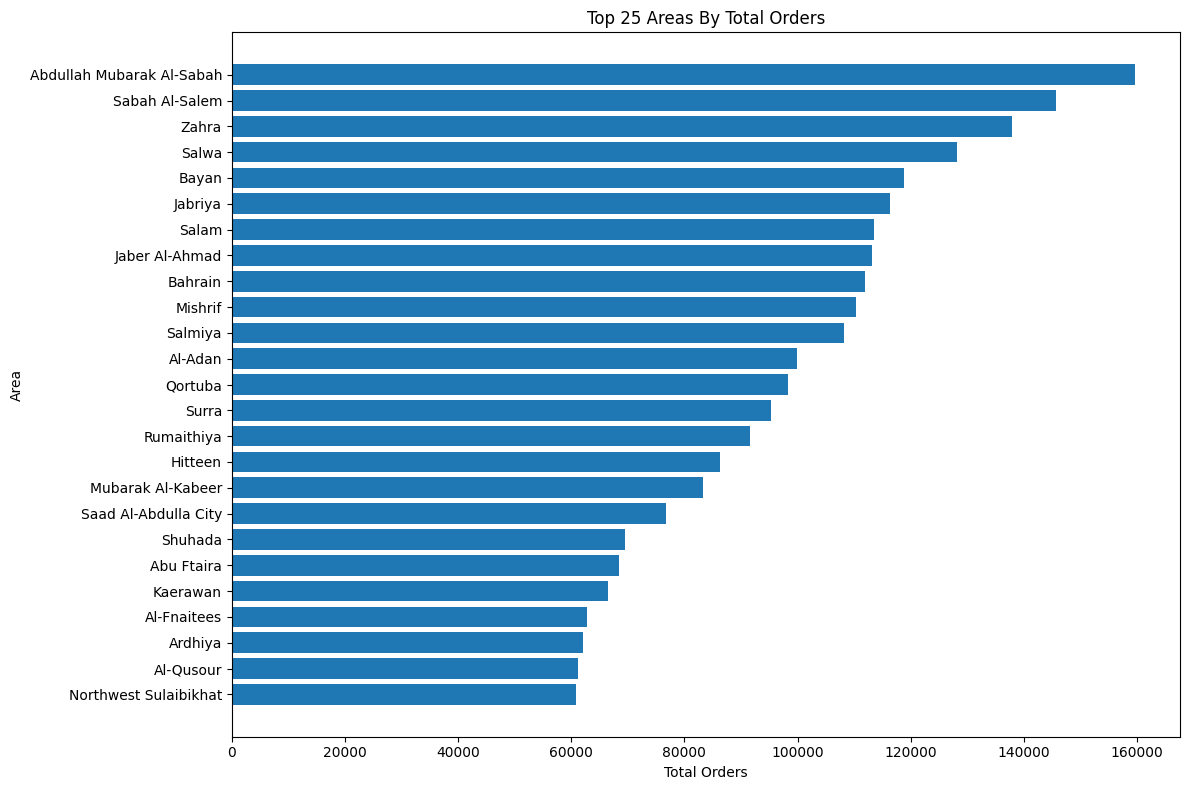

In [9]:
# Plot top areas by order volume.
top_area_volume = area_volume_summary.head(25).sort_values("total_orders")

plt.figure(figsize=(12, 8))
plt.barh(top_area_volume["area"], top_area_volume["total_orders"])
plt.title("Top 25 Areas By Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Area")
plt.tight_layout()
plt.savefig(eda_plot_output_folder_path / "top_25_areas_by_orders.png", dpi=150)
plt.show()

In [10]:
# Inspect the long tail of sparse areas.
area_volume_summary.tail(30)

,area,total_orders,total_driver_requests,observed_hours,first_hour,last_hour,avg_orders_per_observed_hour,avg_requests_per_order,orders_share,cumulative_orders_share,is_modeling_eligible_v1
2043,-Kuwait,1,0,1,2025-07-13 08:00:00+00:00,2025-07-13 08:00:00+00:00,1.0,0.0,2.124326e-07,0.999994,False
2044,وسط الأحمدي,1,3,1,2026-05-09 20:00:00+00:00,2026-05-09 20:00:00+00:00,1.0,3.0,2.124326e-07,0.999994,False
2045,-Mubarak Al Kabeer,1,11,1,2025-03-27 10:00:00+00:00,2025-03-27 10:00:00+00:00,1.0,11.0,2.124326e-07,0.999994,False
2046,منطقة السيف المنامة، المنامة، البحرين,1,3,1,2025-03-02 12:00:00+00:00,2025-03-02 12:00:00+00:00,1.0,3.0,2.124326e-07,0.999994,False
2047,A,1,17,1,2023-11-08 17:00:00+00:00,2023-11-08 17:00:00+00:00,1.0,17.0,2.124326e-07,0.999995,False
2048,Aali -,1,10,1,2022-01-27 14:00:00+00:00,2022-01-27 14:00:00+00:00,1.0,10.0,2.124326e-07,0.999995,False
2049,مقهى ليالى المنشية، المنامة، البحرين,1,10,1,2025-04-20 21:00:00+00:00,2025-04-20 21:00:00+00:00,1.0,10.0,2.124326e-07,0.999995,False
2050,مركز شفاء الجزيرة الطبي، المنامة، البحرين,1,1,1,2024-06-09 16:00:00+00:00,2024-06-09 16:00:00+00:00,1.0,1.0,2.124326e-07,0.999995,False
2051,مركز سترة الصحي، سترة، البحرين,1,7,1,2023-05-25 07:00:00+00:00,2023-05-25 07:00:00+00:00,1.0,7.0,2.124326e-07,0.999996,False
2052,مراسي جاليريا، Marassi Al Bahrain، Bahrain,1,1,1,2025-02-06 10:00:00+00:00,2025-02-06 10:00:00+00:00,1.0,1.0,2.124326e-07,0.999996,False


## 6. Time Coverage And Stability

We check whether the data has stable time coverage and clear temporal patterns.

In [11]:
# Aggregate daily business volume.
daily_business_volume = (
    business_hourly
    .assign(date=business_hourly["window_start"].dt.date)
    .groupby("date", as_index=False)
    .agg(
        orders_count=("orders_count", "sum"),
        driver_requests_count=("driver_requests_count", "sum"),
        active_areas=("area", "nunique"),
    )
)

# Calculate day-over-day order change to detect sudden drops or jumps.
daily_business_volume["orders_pct_change"] = daily_business_volume["orders_count"].pct_change()

daily_business_volume.head()

,date,orders_count,driver_requests_count,active_areas,orders_pct_change
0,2022-01-01,3300,16229,150,NaN
1,2022-01-02,3253,14551,135,-0.014242
2,2022-01-03,2543,9845,134,-0.218260
3,2022-01-04,2334,10650,135,-0.082186
4,2022-01-05,2355,10813,134,0.008997


In [12]:
# Show the largest daily drops in orders.
daily_business_volume.sort_values("orders_pct_change").head(15)

,date,orders_count,driver_requests_count,active_areas,orders_pct_change
1599,2026-05-19,507,1420,138,-0.597619
1096,2025-01-01,3140,6949,235,-0.504732
1511,2026-02-20,1687,2885,217,-0.460333
1563,2026-04-13,910,4457,180,-0.367616
273,2022-10-01,2125,11952,120,-0.367183
1461,2026-01-01,3355,12465,247,-0.361925
1092,2024-12-28,3661,8978,232,-0.333151
1551,2026-04-01,1048,3101,160,-0.332909
91,2022-04-02,2452,7513,120,-0.325818
730,2024-01-01,2730,5181,178,-0.315789


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\stage_armada\\business_load_prediction\\reports\\EDA\\plots\\daily_orders_and_driver_requests.png'

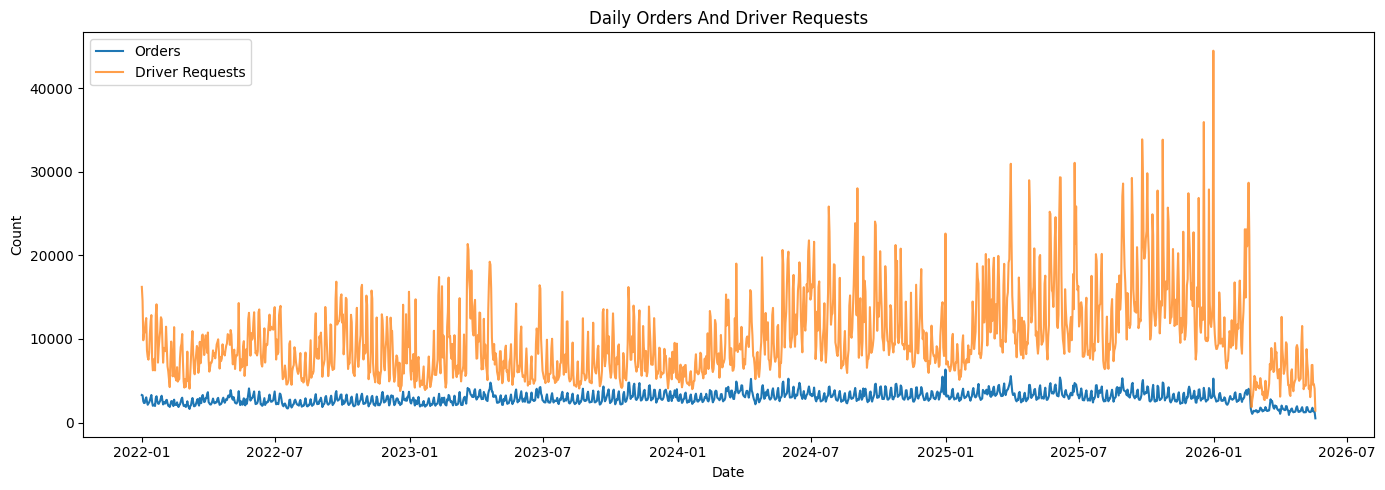

In [13]:
# Plot daily orders and driver requests.
plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(daily_business_volume["date"]), daily_business_volume["orders_count"], label="Orders")
plt.plot(pd.to_datetime(daily_business_volume["date"]), daily_business_volume["driver_requests_count"], label="Driver Requests", alpha=0.75)
plt.title("Daily Orders And Driver Requests")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(eda_plot_output_folder_path / "daily_orders_and_driver_requests.png", dpi=150)
plt.show()

## 7. Order Status Analysis

This section checks order outcomes and whether cancellation/failure signals are meaningful.

In [14]:
# Aggregate order statuses over the full analytical dataset.
order_status_summary = pd.DataFrame([{
    "completed_orders": business_hourly["completed_orders"].sum(),
    "canceled_orders": business_hourly["canceled_orders"].sum(),
    "failed_orders": business_hourly["failed_orders"].sum(),
    "other_orders": business_hourly["other_orders"].sum(),
    "orders_count": business_hourly["orders_count"].sum(),
}])

# Add rates for interpretation.
order_status_summary["completion_rate"] = order_status_summary["completed_orders"] / order_status_summary["orders_count"]
order_status_summary["cancellation_rate"] = order_status_summary["canceled_orders"] / order_status_summary["orders_count"]
order_status_summary["failure_rate"] = order_status_summary["failed_orders"] / order_status_summary["orders_count"]
order_status_summary["other_order_rate"] = order_status_summary["other_orders"] / order_status_summary["orders_count"]

order_status_summary

,completed_orders,canceled_orders,failed_orders,other_orders,orders_count,completion_rate,cancellation_rate,failure_rate,other_order_rate
0,4179796,503619,23769,192,4707376,0.887925,0.106985,0.005049,0.000041


## 8. Driver Request Pressure Analysis

Driver requests are central to pressure forecasting.

Special attention: if `pending` dominates, it may mean status lifecycle behavior rather than real operational pressure.

In [15]:
# Aggregate request statuses over the full analytical dataset.
driver_request_status_summary = pd.DataFrame([{
    "accepted_requests": business_hourly["accepted_requests"].sum(),
    "rejected_requests": business_hourly["rejected_requests"].sum(),
    "ignored_requests": business_hourly["ignored_requests"].sum(),
    "pending_requests": business_hourly["pending_requests"].sum(),
    "driver_requests_count": business_hourly["driver_requests_count"].sum(),
}])

# Add rates for interpretation.
driver_request_status_summary["acceptance_rate"] = driver_request_status_summary["accepted_requests"] / driver_request_status_summary["driver_requests_count"]
driver_request_status_summary["rejection_rate"] = driver_request_status_summary["rejected_requests"] / driver_request_status_summary["driver_requests_count"]
driver_request_status_summary["ignored_rate"] = driver_request_status_summary["ignored_requests"] / driver_request_status_summary["driver_requests_count"]
driver_request_status_summary["pending_rate"] = driver_request_status_summary["pending_requests"] / driver_request_status_summary["driver_requests_count"]

driver_request_status_summary

,accepted_requests,rejected_requests,ignored_requests,pending_requests,driver_requests_count,acceptance_rate,rejection_rate,ignored_rate,pending_rate
0,3937256,2467517,0,9743060,16147833,0.243826,0.152808,0.0,0.603366


In [16]:
# Identify areas with high volume and high request pressure.
high_pressure_area_summary = (
    business_hourly
    .groupby("area", as_index=False)
    .agg(
        total_orders=("orders_count", "sum"),
        total_driver_requests=("driver_requests_count", "sum"),
        avg_requests_per_order=("requests_per_order", "mean"),
        avg_rejection_rate=("rejection_rate", "mean"),
        avg_acceptance_rate=("acceptance_rate", "mean"),
        avg_cancellation_rate=("cancellation_rate", "mean"),
    )
)

# Keep only areas with enough order volume so pressure rates are meaningful.
high_pressure_area_summary = high_pressure_area_summary[high_pressure_area_summary["total_orders"] >= minimum_total_orders_for_modeling]

# Sort by a practical pressure signal.
high_pressure_area_summary.sort_values(
    ["avg_requests_per_order", "avg_rejection_rate", "total_orders"],
    ascending=[False, False, False],
).head(30)

,area,total_orders,total_driver_requests,avg_requests_per_order,avg_rejection_rate,avg_acceptance_rate,avg_cancellation_rate
756,Ishbiliya,1765,15829,9.032147,0.133285,0.282149,0.089564
882,Kuwait City,1945,15969,8.298895,0.134704,0.348383,0.095362
665,Granada,536,4438,8.265382,0.164234,0.244350,0.170385
1428,Sulaibiya Residential,623,4964,8.059697,0.148538,0.251995,0.227121
1258,Sabhan Industrial,971,7559,7.804350,0.097845,0.384864,0.033314
1071,Nahdha,511,3932,7.647917,0.149259,0.362040,0.075868
39,Abdullah Al Mubarak,4692,31196,6.635541,0.084646,0.403658,0.029874
1116,Qairawan,1759,11495,6.609882,0.093773,0.351658,0.138582
1224,Sabah Al Nasser,1224,7846,6.359700,0.086366,0.422101,0.036393
408,Andalous,2029,12663,6.308343,0.139108,0.347988,0.109935


## 9. Seasonality Analysis

Seasonality proves whether forecasting by hour/day makes sense.

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\stage_armada\\business_load_prediction\\reports\\EDA\\plots\\traffic_by_hour_of_day.png'

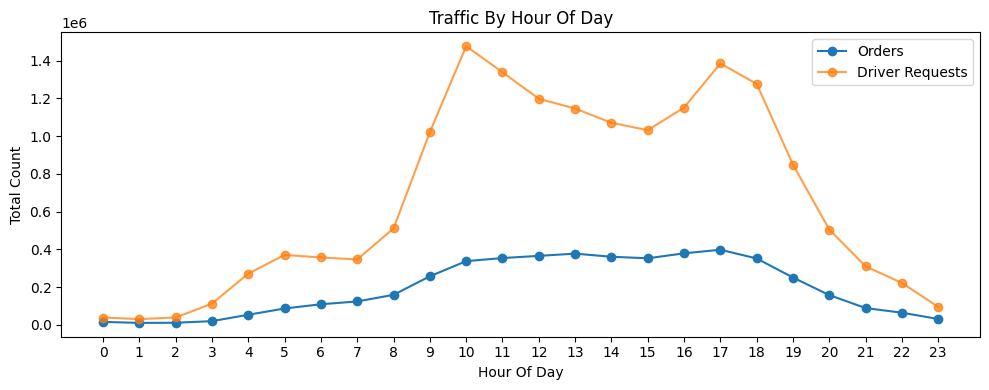

In [17]:
# Orders by hour of day.
orders_by_hour = (
    business_hourly
    .groupby("hour", as_index=False)
    .agg(orders_count=("orders_count", "sum"), driver_requests_count=("driver_requests_count", "sum"))
)

plt.figure(figsize=(10, 4))
plt.plot(orders_by_hour["hour"], orders_by_hour["orders_count"], marker="o", label="Orders")
plt.plot(orders_by_hour["hour"], orders_by_hour["driver_requests_count"], marker="o", label="Driver Requests", alpha=0.75)
plt.title("Traffic By Hour Of Day")
plt.xlabel("Hour Of Day")
plt.ylabel("Total Count")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(eda_plot_output_folder_path / "traffic_by_hour_of_day.png", dpi=150)
plt.show()

orders_by_hour

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\stage_armada\\business_load_prediction\\reports\\EDA\\plots\\orders_by_day_of_week.png'

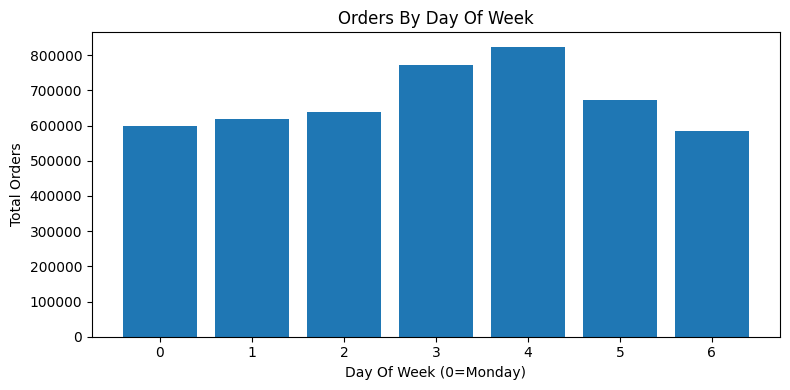

In [18]:
# Orders by day of week.
orders_by_day_of_week = (
    business_hourly
    .groupby("day_of_week", as_index=False)
    .agg(orders_count=("orders_count", "sum"), driver_requests_count=("driver_requests_count", "sum"))
)

plt.figure(figsize=(8, 4))
plt.bar(orders_by_day_of_week["day_of_week"], orders_by_day_of_week["orders_count"])
plt.title("Orders By Day Of Week")
plt.xlabel("Day Of Week (0=Monday)")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.savefig(eda_plot_output_folder_path / "orders_by_day_of_week.png", dpi=150)
plt.show()

orders_by_day_of_week

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\stage_armada\\business_load_prediction\\reports\\EDA\\plots\\orders_day_of_week_by_hour_heatmap.png'

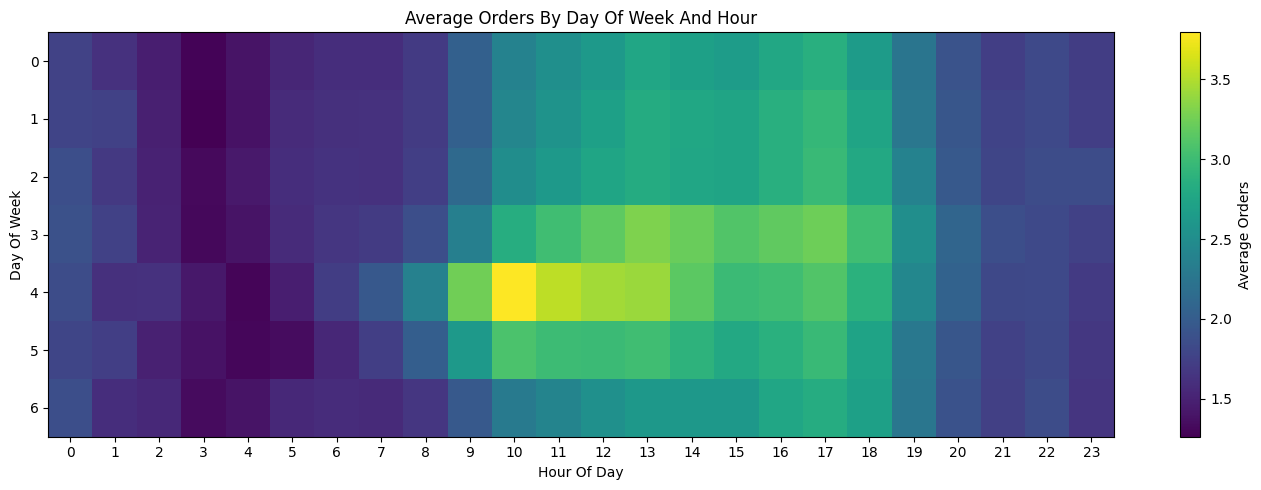

In [19]:
# Heatmap-style table: average orders by day of week and hour.
# This table helps identify repeated weekly/hourly patterns.
orders_day_hour_matrix = (
    business_hourly
    .groupby(["day_of_week", "hour"])["orders_count"]
    .mean()
    .unstack("hour")
)

plt.figure(figsize=(14, 5))
plt.imshow(orders_day_hour_matrix, aspect="auto")
plt.title("Average Orders By Day Of Week And Hour")
plt.xlabel("Hour Of Day")
plt.ylabel("Day Of Week")
plt.colorbar(label="Average Orders")
plt.xticks(range(24), range(24))
plt.yticks(range(len(orders_day_hour_matrix.index)), orders_day_hour_matrix.index)
plt.tight_layout()
plt.savefig(eda_plot_output_folder_path / "orders_day_of_week_by_hour_heatmap.png", dpi=150)
plt.show()

orders_day_hour_matrix

## 10. Technical Pressure Quality And Coverage

Technical pressure has a different data range than business data.

The technical model must use only the time range where logs exist.

In [20]:
# Summarize technical hourly data.
technical_summary = pd.DataFrame([{
    "rows": len(technical_hourly),
    "endpoints": technical_hourly["endpoint"].nunique(),
    "methods": technical_hourly["method"].nunique(),
    "min_window_start": technical_hourly["window_start"].min(),
    "max_window_start": technical_hourly["window_start"].max(),
    "total_api_requests": technical_hourly["request_count"].sum(),
    "total_errors": technical_hourly["error_count"].sum(),
}])

technical_summary

,rows,endpoints,methods,min_window_start,max_window_start,total_api_requests,total_errors
0,102211,256,6,2025-07-17 15:00:00+00:00,2026-05-19 14:00:00+00:00,3231309,0


In [21]:
# Read only response time from staging to inspect invalid raw technical values.
performance_response_time_staging = pd.read_parquet(
    performance_logs_staging_folder_path,
    columns=["responseTime", "statusCode", "createdAt"],
)

performance_response_time_values = pd.to_numeric(performance_response_time_staging["responseTime"], errors="coerce")

technical_response_time_quality_summary = pd.DataFrame([{
    "rows": len(performance_response_time_staging),
    "negative_response_time_count": (performance_response_time_values < 0).sum(),
    "zero_response_time_count": (performance_response_time_values == 0).sum(),
    "min_response_time": performance_response_time_values.min(),
    "p50_response_time": performance_response_time_values.quantile(0.50),
    "p95_response_time": performance_response_time_values.quantile(0.95),
    "p99_response_time": performance_response_time_values.quantile(0.99),
    "max_response_time": performance_response_time_values.max(),
}])

technical_response_time_quality_summary

,rows,negative_response_time_count,zero_response_time_count,min_response_time,p50_response_time,p95_response_time,p99_response_time,max_response_time
0,3231309,1,1,-1891,1767.0,22300.0,39498.0,21485055


In [22]:
# Aggregate technical data by hour to compare with business traffic.
technical_by_hour = (
    technical_hourly
    .groupby("window_start", as_index=False)
    .agg(
        api_request_count=("request_count", "sum"),
        api_error_count=("error_count", "sum"),
        avg_p95_response_time=("p95_response_time", "mean"),
        max_p95_response_time=("p95_response_time", "max"),
    )
)

# Aggregate business data by hour across all areas.
business_by_hour = (
    business_hourly
    .groupby("window_start", as_index=False)
    .agg(
        orders_count=("orders_count", "sum"),
        driver_requests_count=("driver_requests_count", "sum"),
    )
)

# Inner join keeps only overlapping hours where both business and technical data exist.
business_technical_hourly = business_by_hour.merge(technical_by_hour, on="window_start", how="inner")

# Correlation gives a first view of whether business traffic relates to technical pressure.
business_technical_correlation = (
    business_technical_hourly[
        [
            "orders_count",
            "driver_requests_count",
            "api_request_count",
            "api_error_count",
            "avg_p95_response_time",
            "max_p95_response_time",
        ]
    ]
    .corr(method="spearman")
)

business_technical_correlation

,orders_count,driver_requests_count,api_request_count,api_error_count,avg_p95_response_time,max_p95_response_time
orders_count,1.000000,0.926353,0.695746,NaN,0.244376,0.578247
driver_requests_count,0.926353,1.000000,0.665025,NaN,0.244326,0.550231
api_request_count,0.695746,0.665025,1.000000,NaN,0.205609,0.507546
api_error_count,NaN,NaN,NaN,NaN,NaN,NaN
avg_p95_response_time,0.244376,0.244326,0.205609,NaN,1.000000,0.839718
max_p95_response_time,0.578247,0.550231,0.507546,NaN,0.839718,1.000000


## 11. Leakage-Safe Feature Relevance

This section checks which historical signals are related to future traffic.

This is not final model feature selection, but it tells us whether the forecasting direction is valid.

In [23]:
# Create a copy for correlation analysis.
feature_relevance_dataset = business_hourly.copy()

# Future targets: these are values we want to predict before they happen.
feature_relevance_dataset["orders_count_next_1h"] = feature_relevance_dataset.groupby("area")["orders_count"].shift(-1)
feature_relevance_dataset["driver_requests_count_next_1h"] = feature_relevance_dataset.groupby("area")["driver_requests_count"].shift(-1)

# First high-traffic definition uses a global 90th percentile.
# Because many area-hours are low-volume, this threshold should be reviewed during modeling.
global_high_traffic_threshold = feature_relevance_dataset["orders_count"].quantile(0.90)
feature_relevance_dataset["high_traffic_next_1h"] = (
    feature_relevance_dataset["orders_count_next_1h"] >= global_high_traffic_threshold
).astype(float)

# Candidate historical signals.
correlation_candidate_signal_names = [
    "orders_count",
    "driver_requests_count",
    "requests_per_order",
    "rejection_rate",
    "acceptance_rate",
    "cancellation_rate",
]

# Candidate lags.
correlation_candidate_lag_hours = [1, 2, 3, 6, 12, 24, 168]

# Build lagged features only. This avoids same-hour leakage.
for signal_name in correlation_candidate_signal_names:
    if signal_name not in feature_relevance_dataset.columns:
        continue
    for lag_hour in correlation_candidate_lag_hours:
        feature_relevance_dataset[f"{signal_name}_lag_{lag_hour}h"] = (
            feature_relevance_dataset.groupby("area")[signal_name].shift(lag_hour)
        )

# Compute correlation table.
lagged_feature_names = [column_name for column_name in feature_relevance_dataset.columns if "_lag_" in column_name]
future_target_names = ["orders_count_next_1h", "driver_requests_count_next_1h", "high_traffic_next_1h"]

feature_relevance_rows = []

for feature_name in lagged_feature_names:
    for target_name in future_target_names:
        analysis_frame = feature_relevance_dataset[[feature_name, target_name]].dropna()
        if len(analysis_frame) == 0:
            continue
        feature_relevance_rows.append({
            "feature_name": feature_name,
            "target_name": target_name,
            "pearson_correlation": analysis_frame[feature_name].corr(analysis_frame[target_name], method="pearson"),
            "spearman_correlation": analysis_frame[feature_name].corr(analysis_frame[target_name], method="spearman"),
            "rows_used": len(analysis_frame),
        })

feature_relevance_correlation_table = pd.DataFrame(feature_relevance_rows)
feature_relevance_correlation_table["absolute_spearman_correlation"] = feature_relevance_correlation_table["spearman_correlation"].abs()

# Show top features per target.
feature_relevance_correlation_table.sort_values("absolute_spearman_correlation", ascending=False).head(30)

,feature_name,target_name,pearson_correlation,spearman_correlation,rows_used,absolute_spearman_correlation
0,orders_count_lag_1h,orders_count_next_1h,0.462575,0.398893,1884321,0.398893
2,orders_count_lag_1h,high_traffic_next_1h,0.391970,0.345050,1885653,0.345050
3,orders_count_lag_2h,orders_count_next_1h,0.376365,0.334984,1883205,0.334984
12,orders_count_lag_12h,orders_count_next_1h,0.337332,0.333221,1875186,0.333221
5,orders_count_lag_2h,high_traffic_next_1h,0.321723,0.289298,1884321,0.289298
6,orders_count_lag_3h,orders_count_next_1h,0.310915,0.287617,1882199,0.287617
18,orders_count_lag_168h,orders_count_next_1h,0.284076,0.281234,1806925,0.281234
21,driver_requests_count_lag_1h,orders_count_next_1h,0.293010,0.275502,1884321,0.275502
1,orders_count_lag_1h,driver_requests_count_next_1h,0.282032,0.274981,1884321,0.274981
14,orders_count_lag_12h,high_traffic_next_1h,0.281013,0.258011,1875873,0.258011


In [24]:
# Show the strongest features for each future target separately.
strongest_feature_rows = []

for target_name in future_target_names:
    target_rows = (
        feature_relevance_correlation_table
        .query("target_name == @target_name")
        .sort_values("absolute_spearman_correlation", ascending=False)
        .head(10)
    )
    strongest_feature_rows.append(target_rows)

strongest_features_by_target = pd.concat(strongest_feature_rows, ignore_index=True)
strongest_features_by_target

,feature_name,target_name,pearson_correlation,spearman_correlation,rows_used,absolute_spearman_correlation
0,orders_count_lag_1h,orders_count_next_1h,0.462575,0.398893,1884321,0.398893
1,orders_count_lag_2h,orders_count_next_1h,0.376365,0.334984,1883205,0.334984
2,orders_count_lag_12h,orders_count_next_1h,0.337332,0.333221,1875186,0.333221
3,orders_count_lag_3h,orders_count_next_1h,0.310915,0.287617,1882199,0.287617
4,orders_count_lag_168h,orders_count_next_1h,0.284076,0.281234,1806925,0.281234
5,driver_requests_count_lag_1h,orders_count_next_1h,0.293010,0.275502,1884321,0.275502
6,orders_count_lag_24h,orders_count_next_1h,0.231386,0.254977,1867739,0.254977
7,orders_count_lag_6h,orders_count_next_1h,0.223644,0.231902,1879590,0.231902
8,driver_requests_count_lag_2h,orders_count_next_1h,0.235032,0.229104,1883205,0.229104
9,driver_requests_count_lag_12h,orders_count_next_1h,0.202449,0.224573,1875186,0.224573


## 12. Final EDA Decisions For Modeling

Write the decision based on the outputs above.

Suggested interpretation based on current pipeline state:

### Data readiness

- Business hourly data is usable for feature engineering.
- Technical hourly data is usable only from its actual first log date onward.
- Technical response times need cleaning or capping before latency modeling.

### Area strategy

- Model high-volume eligible areas first.
- Sparse areas need fallback baselines, grouping, or separate treatment.

### Strong first-model features

- `hour`, `day_of_week`, cyclic time features
- `orders_count` lags and rolling features
- `driver_requests_count` lags and rolling features
- `requests_per_order` historical features
- `rejection_rate` historical features
- `cancellation_rate` historical features

### Features to avoid in v1

- Current-hour values for future prediction
- raw monetary fields
- raw delivery fee fields
- direct same-hour pressure fields that are not known before prediction
- technical latency until response-time anomalies are handled

### Next phase

Move to feature engineering only after writing the final EDA decision in this notebook.